# This file contains data analyasis performed over full dataset combined for each house

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from load_data import load_data_file, load_data_directory

## Dataset Directorys

In [2]:
dataset_dic = {
    "Dhruv_Patel": {
        "Kitchen": "data/Dhruv_Patel/Kitchen",
        "Hall": "data/Dhruv_Patel/Hall",
        "Bedroom": "data/Dhruv_patel/Bedroom",
    },
    "Harsh_Modi": {
        "Kitchen": "data/Harsh_Modi/Kitchen",
        "Hall": "data/Harsh_Modi/Hall",
        "Bedroom": "data/Harsh_Modi/Bedroom",
    },
    "Honeyy_Barmecha": {
        "Kitchen": "data/Honeyy_Barmecha/Kitchen",
        "Hall": "data/Honeyy_Barmecha/Hall",
        "Bedroom": "data/Honeyy_Barmecha/Bedroom",
    },
    "Parth_Mevada": {
        "Kitchen": "data/Parth_Mevada/Kitchen",
        "Hall": "data/Parth_Mevada/Hall",
        "Bedroom": "data/Parth_Mevada/Bedroom",
    },
}

## Load Data

### Helper function

In [3]:
def get_data(roomPath=None):
    """
    Loads data for the given room using `roomPath` to access the data
    """
    if roomPath is None:
        raise ValueError("parameter roomPath is None")
    else:
        data = load_data_directory(roomPath)
        dfs = []
        if data is not None:
            for file_name, df in data.items():
                if df is not None:
                    dfs.append(df)
        if dfs:
            return pd.concat(dfs, ignore_index=True)

In [4]:
# Dhruv Patel
dhruv_kitchen = get_data(dataset_dic["Dhruv_Patel"]["Kitchen"])
dhruv_hall = get_data(dataset_dic["Dhruv_Patel"]["Hall"])
dhruv_bedroom = get_data(dataset_dic["Dhruv_Patel"]["Bedroom"])

# Harsh Modi
harsh_kitchen = get_data(dataset_dic["Harsh_Modi"]["Kitchen"])
harsh_hall = get_data(dataset_dic["Harsh_Modi"]["Hall"])
harsh_bedroom = get_data(dataset_dic["Harsh_Modi"]["Bedroom"])

# Honeyy Barmech
honeyy_kitchen = get_data(dataset_dic["Honeyy_Barmecha"]["Kitchen"])
honeyy_hall = get_data(dataset_dic["Honeyy_Barmecha"]["Hall"])
honeyy_bedroom = get_data(dataset_dic["Honeyy_Barmecha"]["Bedroom"])

# Parth Mevada
parth_kitchen = get_data(dataset_dic["Parth_Mevada"]["Kitchen"])
parth_hall = get_data(dataset_dic["Parth_Mevada"]["Hall"])
parth_bedroom = get_data(dataset_dic["Parth_Mevada"]["Bedroom"])

Data loaded successfully from data/Dhruv_Patel/Kitchen\ACRL_002_AU_PMS_CAPSTONE_2025-12-31.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel/Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-01.csv, with 7851 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel/Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-02.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel/Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-03.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel/Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-04.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel/Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-05.csv, with 7850 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel/Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-06.csv, with 7851 rows and 15 columns.
Data loaded successfully from data/Dhruv_Patel/Kitchen\ACRL_002_AU_PMS_CAPSTONE_2026-01-07.csv, with 7850 rows 

## Remove None values form the dataset and convert the data in 1 min average

In [5]:
def remove_none_and_average(data, name):
    print(f"{name} shape before removing none values: {data.shape}")
    # Remove None values from all the coloums
    data = data.dropna()
    print(f"{name} shape after removing none values: {data.shape}")

    print(f"{name} shape before 1min average: {data.shape}")
    # Convert to datetime if not already
    data["DateTime"] = pd.to_datetime(data["DateTime"])

    # Set Time as index
    data.set_index("DateTime", inplace=True)

    # Resample to 1 minute averages
    data = data.resample("1min").mean()

    print(f"{name} shape after 1min average: {data.shape}")

    return data

In [6]:
# Dhruv Patel
dhruv_kitchen = remove_none_and_average(dhruv_kitchen, "dhruv_kitchen")
dhruv_hall = remove_none_and_average(dhruv_hall, "dhruv_hall")
dhruv_bedroom = remove_none_and_average(dhruv_bedroom, "dhruv_bedroom")

# Harsh Modi
harsh_kitchen = remove_none_and_average(harsh_kitchen, "harsh_kitchen")
harsh_hall = remove_none_and_average(harsh_hall, "harsh_hall")
harsh_bedroom = remove_none_and_average(harsh_bedroom, "harsh_bedroom")

# Honeyy Barmech
honeyy_kitchen = remove_none_and_average(honeyy_kitchen, "honeyy_kitchen")
honeyy_hall = remove_none_and_average(honeyy_hall, "honeyy_hall")
honeyy_bedroom = remove_none_and_average(honeyy_bedroom, "honeyy_bedroom")

# Parth Mevada
parth_kitchen = remove_none_and_average(parth_kitchen, "parth_kitchen")
parth_hall = remove_none_and_average(parth_hall, "parth_hall")
parth_bedroom = remove_none_and_average(parth_bedroom, "parth_bedroom")

dhruv_kitchen shape before removing none values: (286276, 15)
dhruv_kitchen shape after removing none values: (284724, 15)
dhruv_kitchen shape before 1min average: (284724, 15)
dhruv_kitchen shape after 1min average: (52528, 14)
dhruv_hall shape before removing none values: (282261, 15)
dhruv_hall shape after removing none values: (282228, 15)
dhruv_hall shape before 1min average: (282228, 15)
dhruv_hall shape after 1min average: (52533, 14)
dhruv_bedroom shape before removing none values: (283395, 15)
dhruv_bedroom shape after removing none values: (283379, 15)
dhruv_bedroom shape before 1min average: (283379, 15)
dhruv_bedroom shape after 1min average: (52516, 14)
harsh_kitchen shape before removing none values: (294146, 15)
harsh_kitchen shape after removing none values: (294130, 15)
harsh_kitchen shape before 1min average: (294130, 15)
harsh_kitchen shape after 1min average: (58051, 14)
harsh_hall shape before removing none values: (277177, 15)
harsh_hall shape after removing none 

## Remove outliers

### Helper

In [7]:
def remove_outliers_iqr(df, column, threshold):
    df_clean = df[df[column] <= threshold].copy()
    return df_clean

In [8]:
# Dhruv Patel
dhruv_kitchen = remove_outliers_iqr(dhruv_kitchen, "pm2.5atm", 1500)
dhruv_hall = remove_outliers_iqr(dhruv_hall, "pm2.5atm", 1500)
dhruv_bedroom = remove_outliers_iqr(dhruv_bedroom, "pm2.5atm", 200)

# Harsh Modi
harsh_kitchen = remove_outliers_iqr(harsh_kitchen, "pm2.5atm", 1500)
harsh_hall = remove_outliers_iqr(harsh_hall, "pm2.5atm", 1500)
harsh_bedroom = remove_outliers_iqr(harsh_bedroom, "pm2.5atm", 200)

# Honeyy Barmech
honeyy_kitchen = remove_outliers_iqr(honeyy_kitchen, "pm2.5atm", 1500)
honeyy_hall = remove_outliers_iqr(honeyy_hall, "pm2.5atm", 1500)
honeyy_bedroom = remove_outliers_iqr(honeyy_bedroom, "pm2.5atm", 200)

# Parth Mevada
parth_kitchen = remove_outliers_iqr(parth_kitchen, "pm2.5atm", 1500)
parth_hall = remove_outliers_iqr(parth_hall, "pm2.5atm", 1500)
parth_bedroom = remove_outliers_iqr(parth_bedroom, "pm2.5atm", 200)

## Define colours for plots for kitchen, hall, bedroom

In [9]:
kitchen_colour = "#E41A1C"  # red
hall_colour = "#4DAF4A"  # green
bedroom_colour = "#377EB8"  # blue
shaded_area_colour = "#FF7F00"  # orange
who_guideline_colour = "#984EA3"  # purple
india_guideline_colour = "#A65628"  # brown

## Combine all kitchen, hall, bedroom data in one data frame and group them as per `DateTime`

In [10]:
kitchen = pd.concat([dhruv_kitchen, harsh_kitchen, honeyy_kitchen, parth_kitchen])
hall = pd.concat([dhruv_hall, harsh_hall, honeyy_hall, parth_hall])
bedroom = pd.concat([dhruv_bedroom, harsh_bedroom, honeyy_bedroom, parth_bedroom])

# Group by DateTime and calculate mean
kitchen = kitchen.groupby(kitchen.index).mean()
hall = hall.groupby(hall.index).mean()
bedroom = bedroom.groupby(bedroom.index).mean()

# Remove data prior to date 2025-12-29
cutoff = pd.Timestamp("2025-12-29 00:00")
kitchen = kitchen[pd.to_datetime(kitchen.index) > cutoff]
hall = hall[pd.to_datetime(hall.index) > cutoff]
bedroom = bedroom[pd.to_datetime(bedroom.index) > cutoff]

## Define Plot Directory

In [11]:
PLOT_DIR = "data/Plots"
os.makedirs(PLOT_DIR, exist_ok=True)

## Multi-Day Time Series (Foundation Plot)
- Plot Pm2.5atm vs Time for all three rooms on the same graph
  - then plot new PM2.5atm vs time for each room on the same graph
  - Add horizontal line showing `WHO 24hr guidlines` (25 µg/m³)
  - Add horizontal line showing `India 24hr NAAQS guidlines` (60 µg/m³)
  - save it at `data/Plots/Multi_Day_Time_Series`
  - Calculate percentage time data > `WHO 24hr guidlines` (25 µg/m³) per room
  - Calculate percentage time data > `India 24hr NAAQS guidlines` (60 µg/m³) per room

In [12]:
def multi_day_time_series(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")

    # Create a list of only the `DateTime` and `pm2.5atm` columns for each room
    bedroom_df_subset = bedroom_df[["pm2.5atm"]]
    hall_df_subset = hall_df[["pm2.5atm"]]
    kitchen_df_subset = kitchen_df[["pm2.5atm"]]

    # Plot the perminute average of `pm2.5atm` for each room in a single plot with WHO and INDIA NAAQS guideline line
    plt.figure(figsize=(15, 8))
    plt.plot(
        kitchen_df_subset.index,
        kitchen_df_subset["pm2.5atm"],
        color=kitchen_colour,
        label="Kitchen",
        alpha=0.8,
    )
    plt.plot(
        hall_df_subset.index,
        hall_df_subset["pm2.5atm"],
        color=hall_colour,
        label="Hall",
        alpha=0.8,
    )
    plt.plot(
        bedroom_df_subset.index,
        bedroom_df_subset["pm2.5atm"],
        color=bedroom_colour,
        label="Bedroom",
        alpha=0.8,
    )
    plt.axhline(
        y=25,
        color=who_guideline_colour,
        linestyle="--",
        label="WHO 24hr Guideline (25 µg/m³)",
        linewidth=3,
    )
    plt.axhline(
        y=60,
        color=india_guideline_colour,
        linestyle="--",
        label="India 24hr NAAQS (60 µg/m³)",
        linewidth=3,
    )
    plt.xlabel("Time")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.title("Multi-Day Time Series of PM2.5")
    plt.legend()
    plt.grid(alpha=0.3)
    # Format x-axis to show date and time
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    plt.gca().xaxis.set_major_locator(
        mdates.DayLocator(interval=1)
    )  # Adjust interval as needed
    plt.xticks(rotation=45)
    # Save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "Multi_Day_Time_Series.png"))

    # Show the plot
    plt.show()

    # Calculate percentage time data > WHO 24hr guidlines (25 µg/m³) per room
    kitchen_percentage = (kitchen_df_subset["pm2.5atm"] > 25).mean() * 100
    hall_percentage = (hall_df_subset["pm2.5atm"] > 25).mean() * 100
    bedroom_percentage = (bedroom_df_subset["pm2.5atm"] > 25).mean() * 100

    # Calculate percentage time data > India 24hr NAAQS guidlines (60 µg/m³) per room
    kitchen_percentage_india = (kitchen_df_subset["pm2.5atm"] > 60).mean() * 100
    hall_percentage_india = (hall_df_subset["pm2.5atm"] > 60).mean() * 100
    bedroom_percentage_india = (bedroom_df_subset["pm2.5atm"] > 60).mean() * 100

    print(f"Percentage of time PM2.5 > WHO 24hr Guideline (25 µg/m³):")
    print(f"  Kitchen: {kitchen_percentage:.2f}%")
    print(f"  Hall: {hall_percentage:.2f}%")
    print(f"  Bedroom: {bedroom_percentage:.2f}%")
    print(f"Percentage of time PM2.5 > India 24hr NAAQS (60 µg/m³):")
    print(f"  Kitchen: {kitchen_percentage_india:.2f}%")
    print(f"  Hall: {hall_percentage_india:.2f}%")
    print(f"  Bedroom: {bedroom_percentage_india:.2f}%")

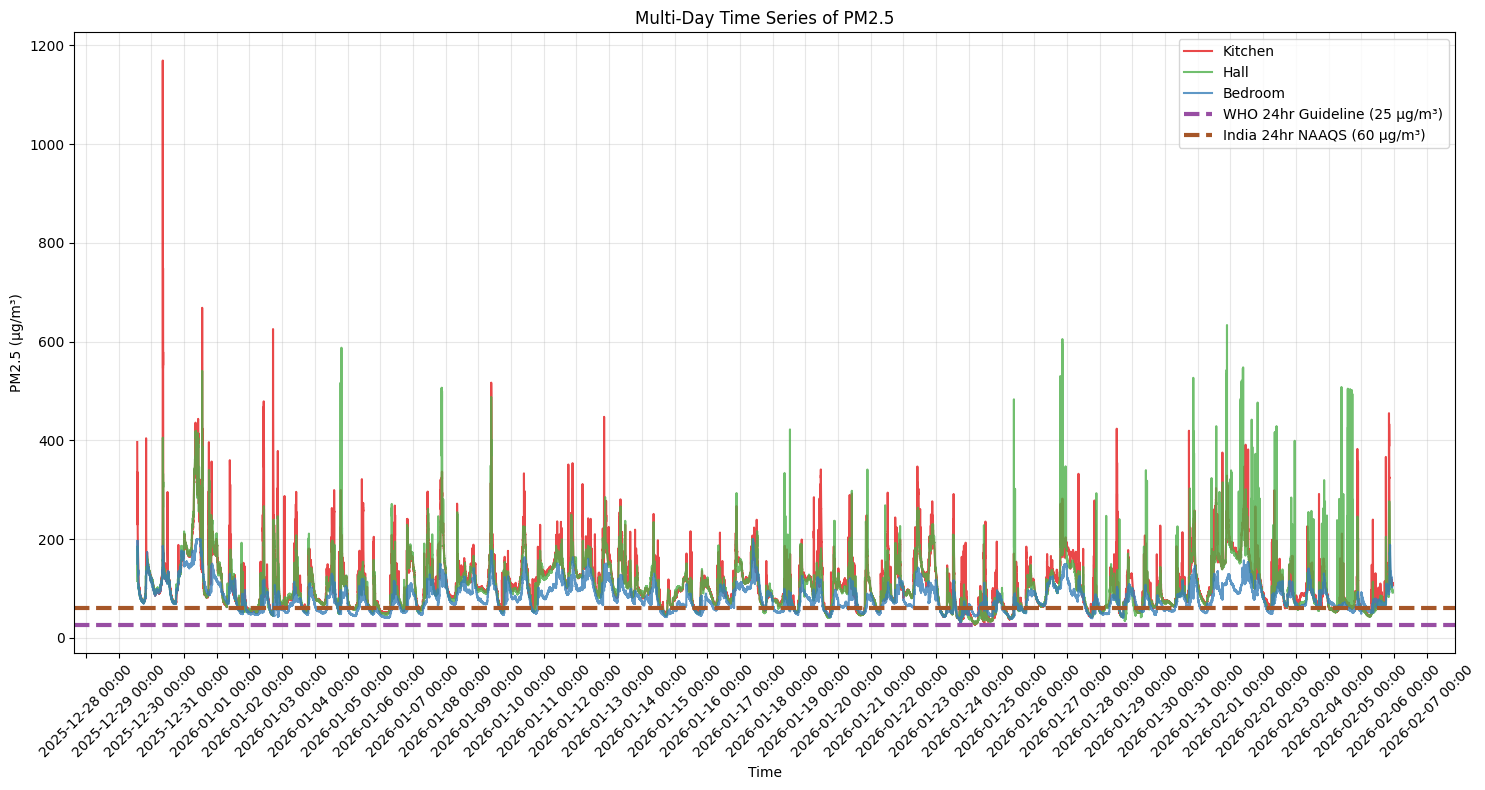

Percentage of time PM2.5 > WHO 24hr Guideline (25 µg/m³):
  Kitchen: 100.00%
  Hall: 100.00%
  Bedroom: 100.00%
Percentage of time PM2.5 > India 24hr NAAQS (60 µg/m³):
  Kitchen: 84.97%
  Hall: 82.49%
  Bedroom: 73.73%


In [13]:
multi_day_time_series(kitchen, hall, bedroom)

## Frequency Analysis.
- Plot data as `pm2.5atm value` -> `Number of appearence'
    - Round off values till 2 decimal points
    - Plot a combined plot for all 3 room
    - Add a vertical line showing `WHO 24hr guidlines` (25 µg/m³)
    - Add a vertical line showing `India 24hr NAAQS guidlines` (60 µg/m³)
    - Save plot to `data\Plots\Frequency_Analysis.png`
- For each room count in wich range 50%, 60%, 70%, 80%, 90% values lies

In [14]:
def frequency_analysis(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")

    # Round off pm2.5atm to nearest integer for frequency counts
    bedroom_vals = bedroom_df["pm2.5atm"].round().dropna().astype(int)
    hall_vals = hall_df["pm2.5atm"].round().dropna().astype(int)
    kitchen_vals = kitchen_df["pm2.5atm"].round().dropna().astype(int)

    # Count occurrences of each pm2.5atm value
    bedroom_freq = bedroom_vals.value_counts().sort_index()
    hall_freq = hall_vals.value_counts().sort_index()
    kitchen_freq = kitchen_vals.value_counts().sort_index()

    # Align all pm2.5atm bins across rooms for plotting
    freq_index = bedroom_freq.index.union(hall_freq.index).union(kitchen_freq.index)
    freq_index = (
        pd.Index(pd.to_numeric(freq_index, errors="coerce")).dropna().sort_values()
    )
    freq_df = pd.DataFrame(
        {
            "pm2.5atm": freq_index,
            "Bedroom": bedroom_freq.reindex(freq_index, fill_value=0).values,
            "Hall": hall_freq.reindex(freq_index, fill_value=0).values,
            "Kitchen": kitchen_freq.reindex(freq_index, fill_value=0).values,
        }
    )

    # Plot the frequency distribution for each room with shaded area
    x = freq_df["pm2.5atm"].to_numpy(dtype=float)
    kitchen_y = freq_df["Kitchen"].to_numpy(dtype=float)
    hall_y = freq_df["Hall"].to_numpy(dtype=float)
    bedroom_y = freq_df["Bedroom"].to_numpy(dtype=float)

    plt.figure(figsize=(15, 8))
    plt.plot(x, kitchen_y, color=kitchen_colour, label="Kitchen", alpha=0.9)
    plt.fill_between(x, kitchen_y, alpha=0.3, color=kitchen_colour)
    plt.plot(x, hall_y, color=hall_colour, label="Hall", alpha=0.9)
    plt.fill_between(x, hall_y, alpha=0.3, color=hall_colour)
    plt.plot(x, bedroom_y, color=bedroom_colour, label="Bedroom", alpha=0.9)
    plt.fill_between(x, bedroom_y, alpha=0.3, color=bedroom_colour)
    plt.xlabel("PM2.5 (µg/m³)")
    plt.ylabel("Frequency (Number of Occurrences)")

    # Add vertical guideline lines for WHO and India limits
    plt.axvline(
        x=25,
        color=who_guideline_colour,
        linestyle="--",
        label="WHO 24hr Guideline (25 µg/m³)",
        linewidth=2,
    )
    plt.axvline(
        x=60,
        color=india_guideline_colour,
        linestyle="--",
        label="India 24hr NAAQS (60 µg/m³)",
        linewidth=2,
    )

    # Set axis limits and show x-axis ticks every 50 units
    x_min, x_max = -5, 1200
    plt.xlim(x_min, x_max)
    plt.xticks(range(0, x_max + 1, 50))

    # Set y-axis limits with a little padding
    y_max = max(freq_df[["Kitchen", "Hall", "Bedroom"]].max()) * 1.1
    plt.ylim(-5, y_max)

    # Mark where the guideline lines meet the x-axis
    y_min, _ = plt.ylim()
    plt.scatter(
        [25, 60],
        [y_min, y_min],
        c=[who_guideline_colour, india_guideline_colour],
        zorder=5,
    )
    plt.annotate(
        "25",
        (25, y_min),
        textcoords="offset points",
        xytext=(0, -12),
        ha="center",
        va="bottom",
        color=who_guideline_colour,
    )
    plt.annotate(
        "60",
        (60, y_min),
        textcoords="offset points",
        xytext=(0, -12),
        ha="center",
        va="bottom",
        color=india_guideline_colour,
    )

    plt.title("Frequency Distribution of PM2.5")
    plt.legend()
    plt.grid(alpha=0.3)
    # Save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "Frequency_Distribution.png"))
    # Show the plot
    plt.show()

    # For each room, calculate the percentage of time pm2.5atm was in the following bins: 0-25, 25-60, >60
    bins = [0, 25, 60, np.inf]
    labels = ["0-25", "25-60", ">60"]
    kitchen_bins = pd.cut(kitchen_vals, bins=bins, labels=labels, right=False)
    hall_bins = pd.cut(hall_vals, bins=bins, labels=labels, right=False)
    bedroom_bins = pd.cut(bedroom_vals, bins=bins, labels=labels, right=False)
    kitchen_bin_counts = kitchen_bins.value_counts(normalize=True) * 100
    hall_bin_counts = hall_bins.value_counts(normalize=True) * 100
    bedroom_bin_counts = bedroom_bins.value_counts(normalize=True) * 100
    print("Percentage of time PM2.5 was in the following bins:")
    print("Kitchen:")
    print(kitchen_bin_counts)
    print("Hall:")
    print(hall_bin_counts)
    print("Bedroom:")
    print(bedroom_bin_counts)

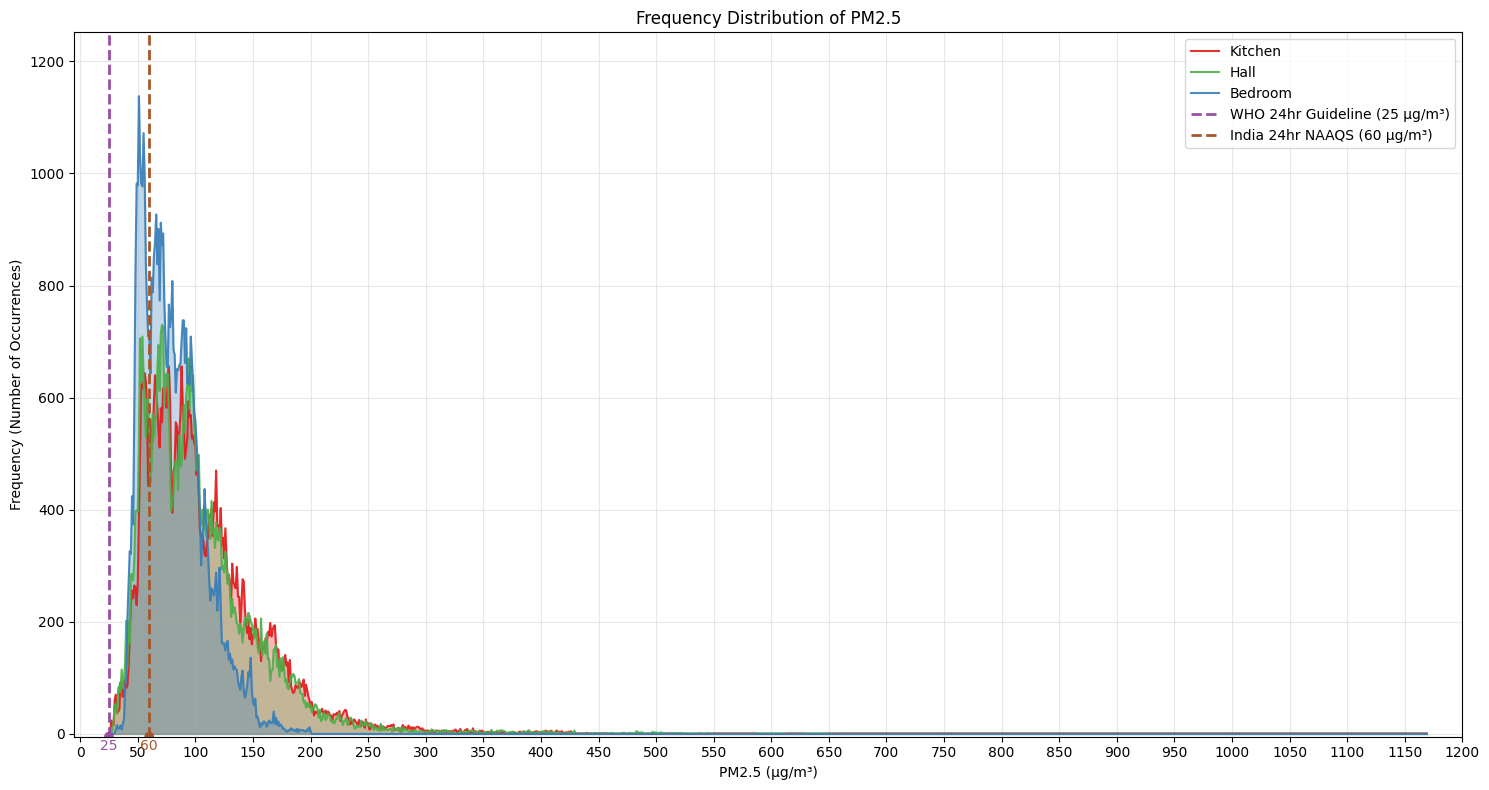

Percentage of time PM2.5 was in the following bins:
Kitchen:
pm2.5atm
>60      85.500326
25-60    14.499674
0-25      0.000000
Name: proportion, dtype: float64
Hall:
pm2.5atm
>60      83.046647
25-60    16.953353
0-25      0.000000
Name: proportion, dtype: float64
Bedroom:
pm2.5atm
>60      74.409313
25-60    25.590687
0-25      0.000000
Name: proportion, dtype: float64


In [15]:
frequency_analysis(kitchen_df=kitchen, hall_df=hall, bedroom_df=bedroom)

## Boxplot Across Days (Strong Academic Figure)
- Create box graph per room
  - Per room per day
- This shows:
  - Day-to-day variability
  - Extreme pollution events
  - Consistency of exposure

In [16]:
def create_daily_boxplot(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")

    # Create a combined DataFrame for boxplot
    kitchen_df = kitchen_df.copy()
    hall_df = hall_df.copy()
    bedroom_df = bedroom_df.copy()
    kitchen_df["Room"] = "Kitchen"
    hall_df["Room"] = "Hall"
    bedroom_df["Room"] = "Bedroom"
    combined_df = pd.concat(
        [
            kitchen_df[["pm2.5atm", "Room"]],
            hall_df[["pm2.5atm", "Room"]],
            bedroom_df[["pm2.5atm", "Room"]],
        ]
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x="Room",
        y="pm2.5atm",
        hue="Room",
        data=combined_df,
        palette=[kitchen_colour, hall_colour, bedroom_colour],
        legend=False,
    )
    plt.ylabel("PM2.5 (µg/m³)")
    plt.title("Daily Boxplot of PM2.5 by Room")
    # Save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "Boxplot.png"))
    # Show the plot
    plt.show()

    # Extract Day from DateTime index for each room and calculate daily average pm2.5atm
    kitchen_daily = kitchen_df.copy()
    hall_daily = hall_df.copy()
    bedroom_daily = bedroom_df.copy()

    kitchen_daily["Day"] = kitchen_df.index.to_series().dt.day.astype(str)
    hall_daily["Day"] = hall_df.index.to_series().dt.day.astype(str)
    bedroom_daily["Day"] = bedroom_df.index.to_series().dt.day.astype(str)

    # Store the dataframes in a dictionary for easy access
    room_dataframes = {
        "Hall": hall_daily,
        "Bedroom": bedroom_daily,
        "Kitchen": kitchen_daily,
    }
    rooms = ["Kitchen", "Hall", "Bedroom"]

    fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=True)

    for idx, room in enumerate(rooms):
        # Get data for current room from the corresponding dataframe
        room_data = room_dataframes[room]

        # Main boxplot (top subplot)
        daily_data = []
        day_labels = []
        daily_stats = []

        for day in sorted(room_data["Day"].unique(), key=int):
            day_values = room_data[room_data["Day"] == day]["pm2.5atm"].values
            if len(day_values) > 0:
                daily_data.append(day_values)
                day_labels.append(f"{day}")
                # Calculate daily statistics
                daily_stats.append(
                    {
                        "mean": np.mean(day_values),
                        "std": np.std(day_values),
                        "cv": np.std(day_values) / np.mean(day_values) * 100,
                        "max": np.max(day_values),
                    }
                )

        # Create main boxplot
        bp = axes[idx].boxplot(daily_data, tick_labels=day_labels, patch_artist=True)

        # Color boxes based on daily mean (gradient from low to high)
        daily_means = [stats["mean"] for stats in daily_stats]
        if daily_means:
            norm = Normalize(vmin=min(daily_means), vmax=max(daily_means))
            cmap = plt.get_cmap("Reds")

            for patch, mean_val in zip(bp["boxes"], daily_means):
                patch.set_facecolor(cmap(norm(mean_val)))
                patch.set_alpha(0.8)

        axes[idx].set_title(f"{room} - Daily PM2.5 Distribution", fontweight="bold")
        axes[idx].set_ylabel("PM2.5 (µg/m³)" if idx == 0 else "")
        axes[idx].grid(True, alpha=0.3)

    fig.suptitle("Comprehensive Daily PM2.5 Analysis", fontsize=16, fontweight="bold")
    fig.tight_layout()
    fig.subplots_adjust(top=0.88)
    # Save the plot
    fig.savefig(os.path.join(PLOT_DIR, "Daily_Boxplot_Analysis.png"))
    # Show the plot
    plt.show()

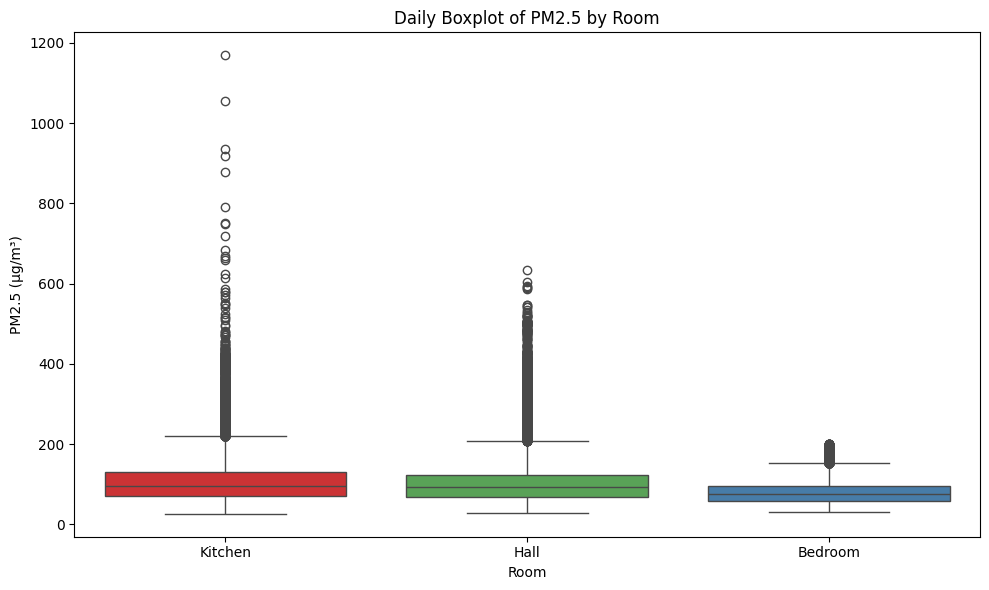

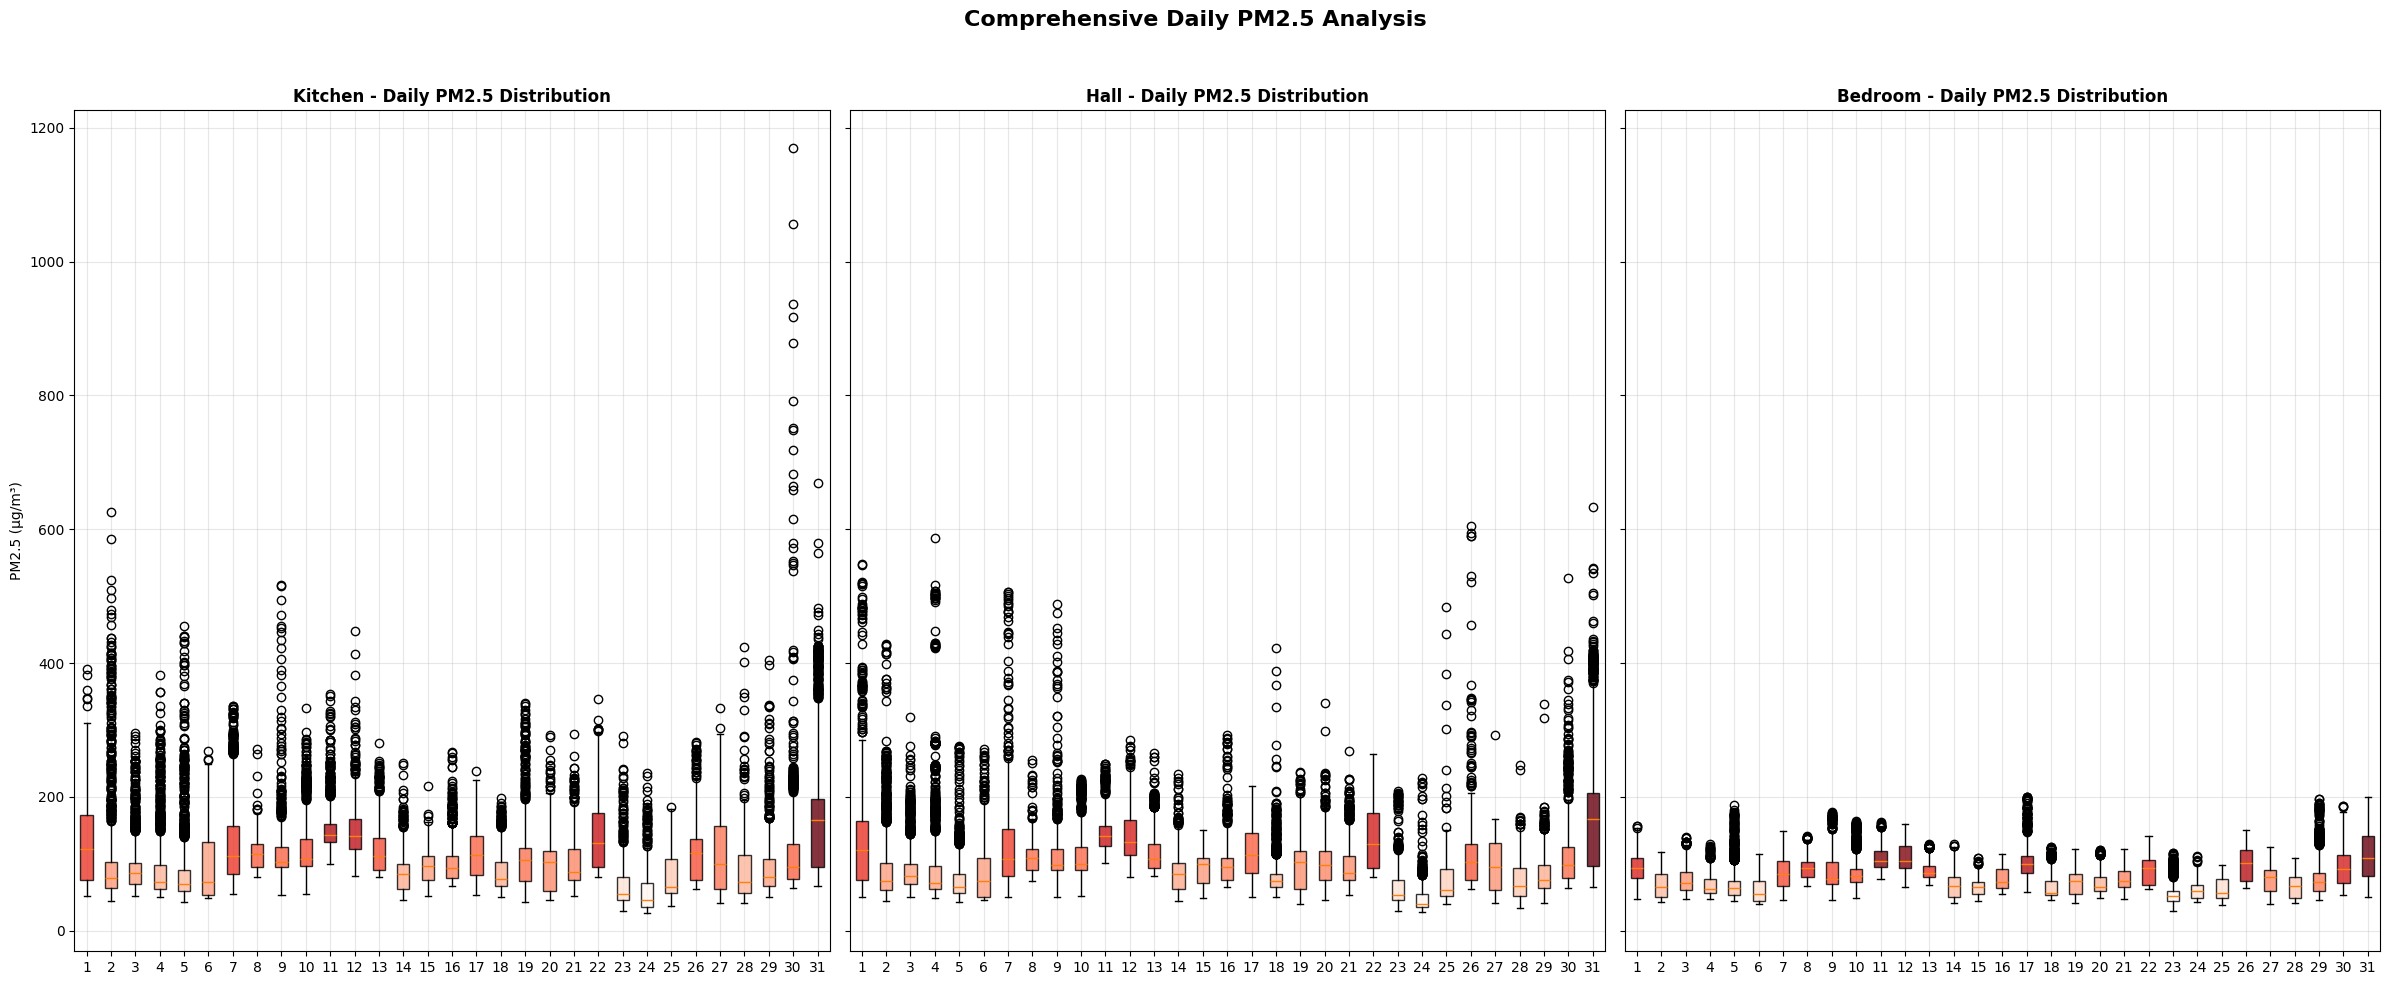

In [17]:
create_daily_boxplot(kitchen_df=kitchen, hall_df=hall, bedroom_df=bedroom)

## Diurnal Pattern (MOST IMPORTANT FOR SOURCE IDENTIFICATION)
#### Step:
- Extract hour from DateTime
- Compute average PM2.5 for each hour (across all days)

#### Plot:
- Hour (0–23) vs Average PM2.5
- Make single curves for:
  - Bedroom
  - Hall
  - Kitchen

In [18]:
def diurnal_pattern(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")

    # Create a list of only the pm2.5atm` columns for each room
    bedroom_hourly_df = bedroom_df[["pm2.5atm"]]
    hall_hourly_df = hall_df[["pm2.5atm"]]
    kitchen_hourly_df = kitchen_df[["pm2.5atm"]]

    # Create a new column for the hour of the day in each dataframe
    bedroom_hourly_df["Hour"] = bedroom_hourly_df.index.to_series().dt.hour
    hall_hourly_df["Hour"] = hall_hourly_df.index.to_series().dt.hour
    kitchen_hourly_df["Hour"] = kitchen_hourly_df.index.to_series().dt.hour

    # Calculate the average `pm2.5atm` for each hour of the day for each room
    bedroom_hourly_avg = bedroom_hourly_df.groupby("Hour")["pm2.5atm"].mean()
    hall_hourly_avg = hall_hourly_df.groupby("Hour")["pm2.5atm"].mean()
    kitchen_hourly_avg = kitchen_hourly_df.groupby("Hour")["pm2.5atm"].mean()

    # Plot the diurnal pattern for each room
    plt.figure(figsize=(15, 6))
    plt.plot(
        kitchen_hourly_avg.index,
        kitchen_hourly_avg.values,
        color=kitchen_colour,
        label="Kitchen",
        alpha=0.8,
    )
    plt.plot(
        hall_hourly_avg.index,
        hall_hourly_avg.values,
        color=hall_colour,
        label="Hall",
        alpha=0.8,
    )
    plt.plot(
        bedroom_hourly_avg.index,
        bedroom_hourly_avg.values,
        color=bedroom_colour,
        label="Bedroom",
        alpha=0.8,
    )
    plt.xlabel("Hour of the Day")
    plt.xticks(range(0, 24, 1))
    plt.ylabel("Average PM2.5 (µg/m³)")
    plt.title("Diurnal Pattern of PM2.5")
    plt.legend()
    plt.grid(alpha=0.3)
    # Save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "Diurnal_Pattern.png"))
    # Show the plot
    plt.show()

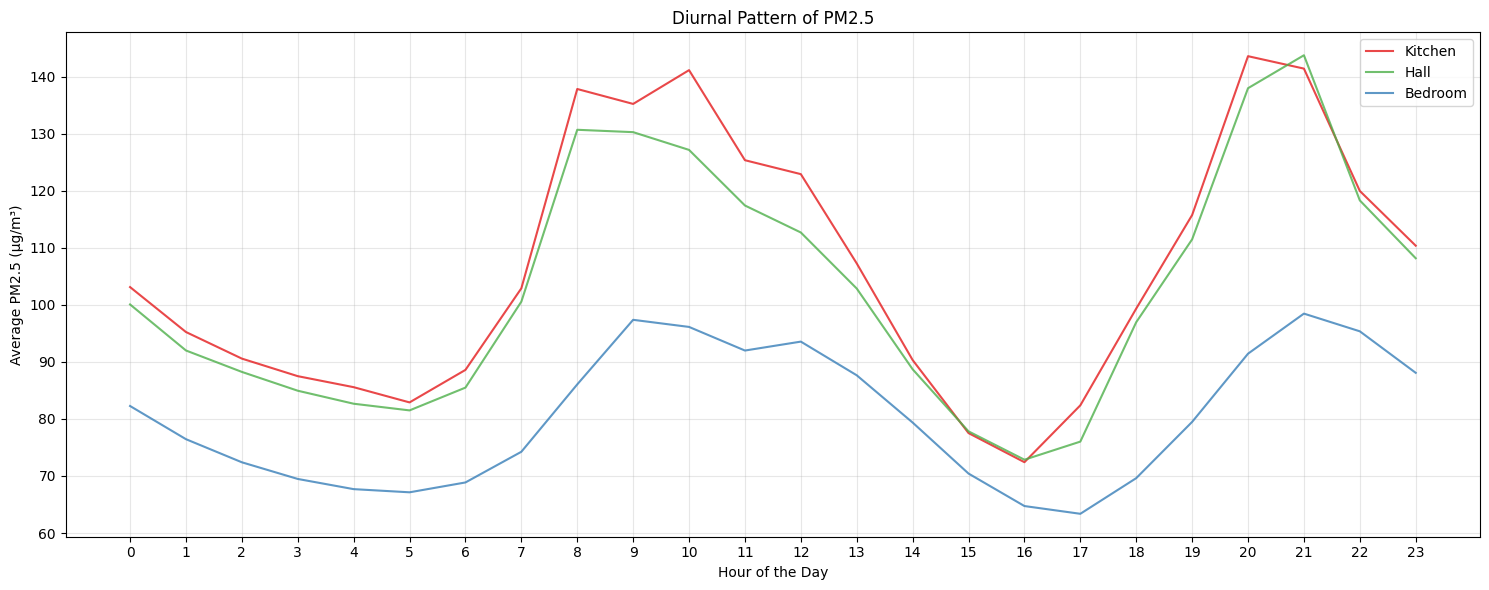

In [19]:
diurnal_pattern(kitchen_df=kitchen, hall_df=hall, bedroom_df=bedroom)

## Peak Event Analysis
#### Define peak event thresholds
- For each daily average as threshold
#### Calculations:
- For each day calculate:
  - Number of peaks
  - Duration of peaks
  - Maximum peak concentration
  - Note for each rooms

In [20]:
def peak_event_analysis(kitchen_df=None, hall_df=None, bedroom_df=None):
    if kitchen_df is None:
        raise ValueError("kitchen_df is None")
    if hall_df is None:
        raise ValueError("hall_df is None")
    if bedroom_df is None:
        raise ValueError("bedroom_df is None")

    # Create a list of only the 'DateTime' index and `pm2.5atm` columns for each room
    kitchen_peak_df = kitchen_df[["pm2.5atm"]]
    hall_peak_df = hall_df[["pm2.5atm"]]
    bedroom_peak_df = bedroom_df[["pm2.5atm"]]

    # Calculate average of each date for each room
    kitchen_peak_df["Date"] = kitchen_peak_df.index.date
    hall_peak_df["Date"] = hall_peak_df.index.date
    bedroom_peak_df["Date"] = bedroom_peak_df.index.date
    kitchen_daily_avg = kitchen_peak_df.groupby("Date")["pm2.5atm"].mean()
    hall_daily_avg = hall_peak_df.groupby("Date")["pm2.5atm"].mean()
    bedroom_daily_avg = bedroom_peak_df.groupby("Date")["pm2.5atm"].mean()

    # Create a new column to identify peak events for each room based on the same day average
    kitchen_peak_df = kitchen_peak_df.merge(
        kitchen_daily_avg.rename("DailyAvg"), left_on="Date", right_index=True
    )
    hall_peak_df = hall_peak_df.merge(
        hall_daily_avg.rename("DailyAvg"), left_on="Date", right_index=True
    )
    bedroom_peak_df = bedroom_peak_df.merge(
        bedroom_daily_avg.rename("DailyAvg"), left_on="Date", right_index=True
    )
    kitchen_peak_df["Peak Event"] = (
        kitchen_peak_df["pm2.5atm"] > kitchen_peak_df["DailyAvg"]
    )
    hall_peak_df["Peak Event"] = hall_peak_df["pm2.5atm"] > hall_peak_df["DailyAvg"]
    bedroom_peak_df["Peak Event"] = (
        bedroom_peak_df["pm2.5atm"] > bedroom_peak_df["DailyAvg"]
    )

    # Ensure that data frames are sorted by DateTime
    kitchen_peak_df.sort_index(inplace=True)
    hall_peak_df.sort_index(inplace=True)
    bedroom_peak_df.sort_index(inplace=True)

    # Identify Peack Start
    bedroom_peak_df["Peak Start"] = (bedroom_peak_df["Peak Event"] == True) & (
        bedroom_peak_df["Peak Event"].shift(1) == False
    )
    hall_peak_df["Peak Start"] = (hall_peak_df["Peak Event"] == True) & (
        hall_peak_df["Peak Event"].shift(1) == False
    )
    kitchen_peak_df["Peak Start"] = (kitchen_peak_df["Peak Event"] == True) & (
        kitchen_peak_df["Peak Event"].shift(1) == False
    )

    # Assign a unique ID to each peak event
    bedroom_peak_df["Peak ID"] = bedroom_peak_df["Peak Start"].cumsum()
    hall_peak_df["Peak ID"] = hall_peak_df["Peak Start"].cumsum()
    kitchen_peak_df["Peak ID"] = kitchen_peak_df["Peak Start"].cumsum()

    # All days in the dataset for each room to ensure we keep days with no peak events in the analysis
    all_days = pd.date_range(
        start=bedroom_peak_df["Date"].min(), end=bedroom_peak_df["Date"].max()
    ).date

    # Remove non peak events
    bedroom_peak_df = bedroom_peak_df[bedroom_peak_df["Peak Event"] == True]
    hall_peak_df = hall_peak_df[hall_peak_df["Peak Event"] == True]
    kitchen_peak_df = kitchen_peak_df[kitchen_peak_df["Peak Event"] == True]

    # Count number of peak events per day for each room
    bedroom_peak_events_per_day = (
        bedroom_peak_df.groupby("Date")["Peak ID"]
        .nunique()
        .reset_index(name="Peak Events")
    )
    hall_peak_events_per_day = (
        hall_peak_df.groupby("Date")["Peak ID"]
        .nunique()
        .reset_index(name="Peak Events")
    )
    kitchen_peak_events_per_day = (
        kitchen_peak_df.groupby("Date")["Peak ID"]
        .nunique()
        .reset_index(name="Peak Events")
    )
    # Keep days with no peak events as well
    bedroom_peak_events_per_day = (
        bedroom_peak_events_per_day.set_index("Date")
        .reindex(all_days, fill_value=0)
        .reset_index()
        .rename(columns={"index": "Date"})
    )
    hall_peak_events_per_day = (
        hall_peak_events_per_day.set_index("Date")
        .reindex(all_days, fill_value=0)
        .reset_index()
        .rename(columns={"index": "Date"})
    )
    kitchen_peak_events_per_day = (
        kitchen_peak_events_per_day.set_index("Date")
        .reindex(all_days, fill_value=0)
        .reset_index()
        .rename(columns={"index": "Date"})
    )

    # Calculate Duration of Each Peak Event with Day
    bedroom_peak_duration = (
        bedroom_peak_df.reset_index()
        .groupby(["Date", "Peak ID"])
        .agg(min_time=("DateTime", "min"), max_time=("DateTime", "max"))
        .reset_index()
    )
    hall_peak_duration = (
        hall_peak_df.reset_index()
        .groupby(["Date", "Peak ID"])
        .agg(min_time=("DateTime", "min"), max_time=("DateTime", "max"))
        .reset_index()
    )
    kitchen_peak_duration = (
        kitchen_peak_df.reset_index()
        .groupby(["Date", "Peak ID"])
        .agg(min_time=("DateTime", "min"), max_time=("DateTime", "max"))
        .reset_index()
    )
    bedroom_peak_duration["Duration (minutes)"] = (
        bedroom_peak_duration["max_time"] - bedroom_peak_duration["min_time"]
    ).dt.total_seconds() / 60
    hall_peak_duration["Duration (minutes)"] = (
        hall_peak_duration["max_time"] - hall_peak_duration["min_time"]
    ).dt.total_seconds() / 60
    kitchen_peak_duration["Duration (minutes)"] = (
        kitchen_peak_duration["max_time"] - kitchen_peak_duration["min_time"]
    ).dt.total_seconds() / 60
    # Replace 0.0 with 1/60 to avoid zero duration
    bedroom_peak_duration["Duration (minutes)"] = bedroom_peak_duration[
        "Duration (minutes)"
    ].replace(0.0, 1 / 60)
    hall_peak_duration["Duration (minutes)"] = hall_peak_duration[
        "Duration (minutes)"
    ].replace(0.0, 1 / 60)
    kitchen_peak_duration["Duration (minutes)"] = kitchen_peak_duration[
        "Duration (minutes)"
    ].replace(0.0, 1 / 60)

    # Maximum Peak Concentration Per Day
    bedroom_peak_max = (
        bedroom_peak_df.groupby("Date")["pm2.5atm"]
        .max()
        .reset_index(name="Max pm2.5atm")
    )
    hall_peak_max = (
        hall_peak_df.groupby("Date")["pm2.5atm"].max().reset_index(name="Max pm2.5atm")
    )
    kitchen_peak_max = (
        kitchen_peak_df.groupby("Date")["pm2.5atm"]
        .max()
        .reset_index(name="Max pm2.5atm")
    )

    # Save the peak event analysis results to CSV files
    os.makedirs(f"{PLOT_DIR}/Peak_Event_Analysis", exist_ok=True)

    # Number of peak events per day for each room
    bedroom_peak_events_per_day.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/bedroom_peak_events_per_day.csv", index=False
    )
    hall_peak_events_per_day.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/hall_peak_events_per_day.csv", index=False
    )
    kitchen_peak_events_per_day.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/kitchen_peak_events_per_day.csv", index=False
    )

    # Duration of each peak event for each room
    bedroom_peak_duration.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/bedroom_peak_duration.csv", index=False
    )
    hall_peak_duration.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/hall_peak_duration.csv", index=False
    )
    kitchen_peak_duration.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/kitchen_peak_duration.csv", index=False
    )

    # Maximum peak concentration per day for each room
    bedroom_peak_max.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/bedroom_peak_max.csv", index=False
    )
    hall_peak_max.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/hall_peak_max.csv", index=False
    )
    kitchen_peak_max.to_csv(
        f"{PLOT_DIR}/Peak_Event_Analysis/kitchen_peak_max.csv", index=False
    )

    # For each room print total number of peak events, average duration of peak events, max duration of peak events, and average maximum concentration, max maximum concentration during peak events
    # Bedroom
    print(
        f"Total number of peak events - Bedroom: {bedroom_peak_df['Peak ID'].nunique()}"
    )
    print(
        f"Average duration of peak events (minutes) - Bedroom: {bedroom_peak_duration['Duration (minutes)'].mean():.2f}"
    )
    print(
        f"Max duration of peak events (minutes) - Bedroom: {bedroom_peak_duration['Duration (minutes)'].max():.2f}"
    )
    print(
        f"Average maximum concentration during peak events (µg/m³) - Bedroom: {bedroom_peak_max['Max pm2.5atm'].mean():.2f}"
    )
    print(
        f"Max maximum concentration during peak events (µg/m³) - Bedroom: {bedroom_peak_max['Max pm2.5atm'].max():.2f}"
    )
    # Hall
    print(f"\nTotal number of peak events - Hall: {hall_peak_df['Peak ID'].nunique()}")
    print(
        f"Average duration of peak events (minutes) - Hall: {hall_peak_duration['Duration (minutes)'].mean():.2f}"
    )
    print(
        f"Max duration of peak events (minutes) - Hall: {hall_peak_duration['Duration (minutes)'].max():.2f}"
    )
    print(
        f"Average maximum concentration during peak events (µg/m³) - Hall: {hall_peak_max['Max pm2.5atm'].mean():.2f}"
    )
    print(
        f"Max maximum concentration during peak events (µg/m³) - Hall: {hall_peak_max['Max pm2.5atm'].max():.2f}"
    )
    # Kitchen
    print(
        f"\nTotal number of peak events - Kitchen: {kitchen_peak_df['Peak ID'].nunique()}"
    )
    print(
        f"Average duration of peak events (minutes) - Kitchen: {kitchen_peak_duration['Duration (minutes)'].mean():.2f}"
    )
    print(
        f"Max duration of peak events (minutes) - Kitchen: {kitchen_peak_duration['Duration (minutes)'].max():.2f}"
    )
    print(
        f"Average maximum concentration during peak events (µg/m³) - Kitchen: {kitchen_peak_max['Max pm2.5atm'].mean():.2f}"
    )
    print(
        f"Max maximum concentration during peak events (µg/m³) - Kitchen: {kitchen_peak_max['Max pm2.5atm'].max():.2f}"
    )

    # Plot the number of peak events per day for each room
    plt.figure(figsize=(10, 5))
    plt.plot(
        kitchen_peak_events_per_day["Date"],
        kitchen_peak_events_per_day["Peak Events"],
        color=kitchen_colour,
        label="Kitchen",
        alpha=0.8,
    )
    plt.plot(
        hall_peak_events_per_day["Date"],
        hall_peak_events_per_day["Peak Events"],
        color=hall_colour,
        label="Hall",
        alpha=0.8,
    )
    plt.plot(
        bedroom_peak_events_per_day["Date"],
        bedroom_peak_events_per_day["Peak Events"],
        color=bedroom_colour,
        label="Bedroom",
        alpha=0.8,
    )
    plt.xlabel("Date")
    plt.ylabel("Number of Peak Events")
    plt.title("Number of Peak Events per Day")
    plt.legend()
    plt.grid(alpha=0.3)
    # Format x-axis to show date
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(
        ticks=all_days,
        labels=[day.strftime("%Y-%m-%d") for day in all_days],
        rotation=75,
    )
    # Save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "Peak_Event_Analysis/Peak_Events_Per_Day.png"))
    # Show the plot
    plt.show()

    # Plot the Average & Max duration of peak events for each room
    plt.figure(figsize=(10, 5))
    plt.plot(
        kitchen_peak_duration.groupby("Date")["Duration (minutes)"].mean(),
        color=kitchen_colour,
        label="Kitchen - Average Duration",
        alpha=0.8,
    )
    plt.plot(
        hall_peak_duration.groupby("Date")["Duration (minutes)"].mean(),
        color=hall_colour,
        label="Hall - Average Duration",
        alpha=0.8,
    )
    plt.plot(
        bedroom_peak_duration.groupby("Date")["Duration (minutes)"].mean(),
        color=bedroom_colour,
        label="Bedroom - Average Duration",
        alpha=0.8,
    )
    plt.plot(
        kitchen_peak_duration.groupby("Date")["Duration (minutes)"].max(),
        color=kitchen_colour,
        linestyle="--",
        alpha=0.8,
        label="Kitchen - Max Duration",
    )
    plt.plot(
        hall_peak_duration.groupby("Date")["Duration (minutes)"].max(),
        color=hall_colour,
        linestyle="--",
        alpha=0.8,
        label="Hall - Max Duration",
    )
    plt.plot(
        bedroom_peak_duration.groupby("Date")["Duration (minutes)"].max(),
        color=bedroom_colour,
        linestyle="--",
        alpha=0.8,
        label="Bedroom - Max Duration",
    )
    plt.xlabel("Date")
    plt.ylabel("Duration of Peak Events (minutes)")
    plt.title("Duration of Peak Events per Day")
    plt.legend()
    plt.grid(alpha=0.3)
    # Format x-axis to show date
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(
        ticks=all_days,
        labels=[day.strftime("%Y-%m-%d") for day in all_days],
        rotation=75,
    )
    # Save the plot
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOT_DIR, "Peak_Event_Analysis/Peak_Event_Duration_Per_Day.png")
    )
    # Show the plot
    plt.show()

    # Plot the Average & Maximum concentration during peak events for each room
    plt.figure(figsize=(10, 5))
    plt.plot(
        kitchen_peak_max.groupby("Date")["Max pm2.5atm"].mean(),
        color=kitchen_colour,
        label="Kitchen - Average maximum Concentration",
        alpha=0.8,
    )
    plt.plot(
        hall_peak_max.groupby("Date")["Max pm2.5atm"].mean(),
        color=hall_colour,
        label="Hall - Average maximum Concentration",
        alpha=0.8,
    )
    plt.plot(
        bedroom_peak_max.groupby("Date")["Max pm2.5atm"].mean(),
        color=bedroom_colour,
        label="Bedroom - Average maximum Concentration",
        alpha=0.8,
    )
    plt.xlabel("Date")
    plt.ylabel("PM2.5 Concentration During Peak Events (µg/m³)")
    plt.title("Concentration During Peak Events per Day")
    plt.legend()
    plt.grid(alpha=0.3)
    # Format x-axis to show date
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(
        ticks=all_days,
        labels=[day.strftime("%Y-%m-%d") for day in all_days],
        rotation=75,
    )
    # Save the plot
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            PLOT_DIR, "Peak_Event_Analysis/Peak_Event_Concentration_Per_Day.png"
        )
    )
    # Show the plot
    plt.show()

Total number of peak events - Bedroom: 550
Average duration of peak events (minutes) - Bedroom: 43.22
Max duration of peak events (minutes) - Bedroom: 831.00
Average maximum concentration during peak events (µg/m³) - Bedroom: 137.74
Max maximum concentration during peak events (µg/m³) - Bedroom: 199.98

Total number of peak events - Hall: 520
Average duration of peak events (minutes) - Hall: 40.15
Max duration of peak events (minutes) - Hall: 575.00
Average maximum concentration during peak events (µg/m³) - Hall: 337.91
Max maximum concentration during peak events (µg/m³) - Hall: 633.58

Total number of peak events - Kitchen: 545
Average duration of peak events (minutes) - Kitchen: 38.84
Max duration of peak events (minutes) - Kitchen: 525.00
Average maximum concentration during peak events (µg/m³) - Kitchen: 358.69
Max maximum concentration during peak events (µg/m³) - Kitchen: 1169.33


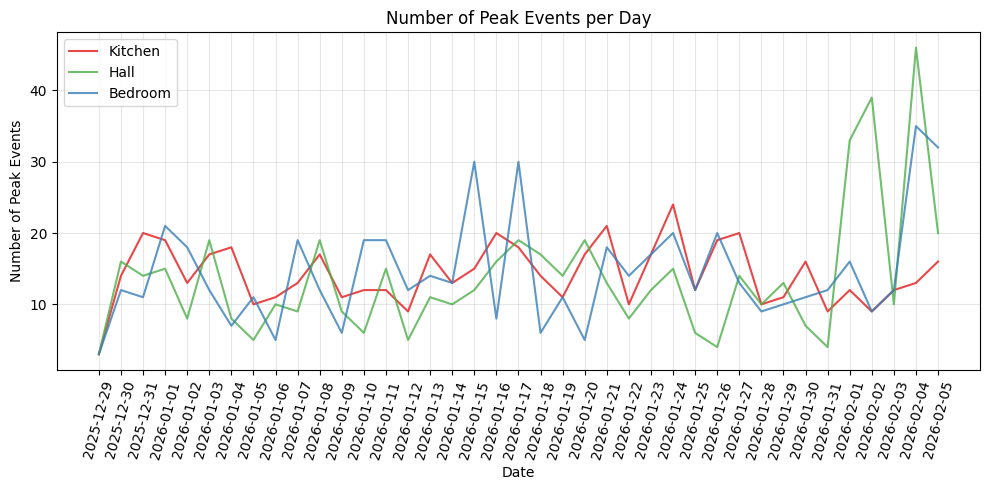

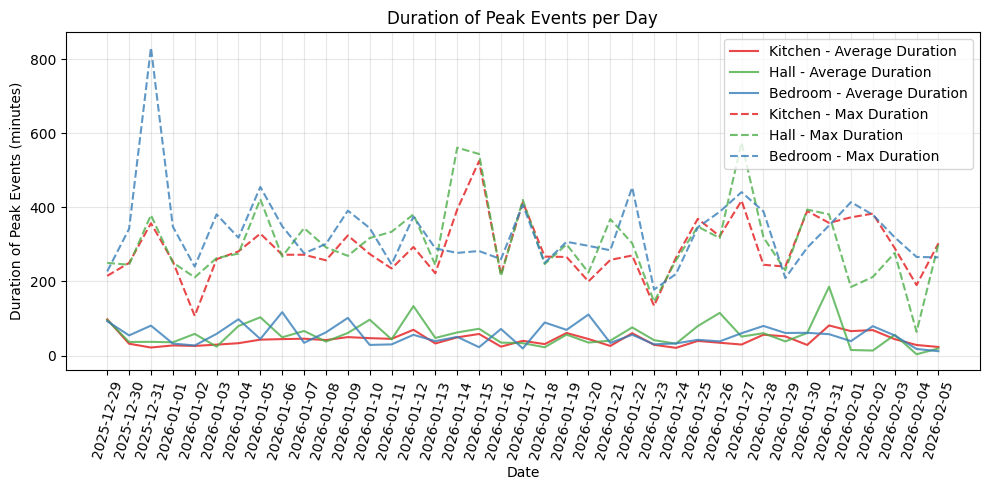

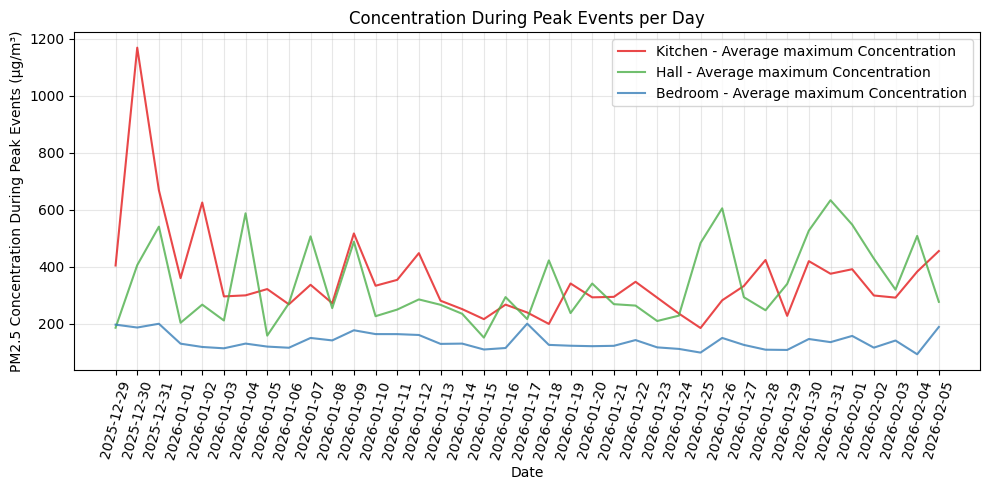

In [21]:
peak_event_analysis(kitchen_df=kitchen, hall_df=hall, bedroom_df=bedroom)

## Cooking-Related PM2.5 Contribution Analysis
#### Define cooking windows (This are general and most prefered not always correct)
- Morning + Afternoon : 6:00 to 12:00 (From morning tea to Lunch)
- Evening : 17:00 to 22:00 (From evening tea to Dinner)
#### Steps
- Crate a dataframe with `DateTime` and `pm2.5atm` as coloums
- Add coloums `hour`, `minute`, `time`
- Add coloums `Period` which classifies each entry as `Morning Cooking + Lunch`, `Evening Cooking + Dinner`, and `Non-Cooking`
- Compare `Mean`, `Max`, `Standard Deviation` of `pm2.5atm` by Period
- Compare Peak Frequency by Period
- Exposure Contribution Analysis
  - Calculate Total `pm2.5atm` during cooking vs total daily `pm2.5atm`
  - Then compute percentage
- Plot Diurnal Curve With Shaded Cooking Windows
  - Plot hourly average `pm2.5atm`
  - Then highlight Cooking durations
- Room-Wise Cooking Impact
  - Repeat analysis separately for:
    - Kitchen
    - Hall
    - Bedroom

In [22]:
from datetime import time


def classify_period(t):
    """
    Morning + Afternoon : 6:00 to 12:00 (From morning tea to Lunch)
    Evening : 17:00 to 22:00 (From evening tea to Dinner)
    """
    if time(6, 0) <= t <= time(12, 0):
        return "Morning Cooking + Lunch"
    elif time(17, 0) <= t <= time(22, 0):
        return "Evening Cooking + Dinner"
    else:
        return "Non-Cooking"


def get_total_hours(period):
    if period == "Morning Cooking + Lunch":
        return 6  # 6-12
    elif period == "Evening Cooking + Dinner":
        return 5  # 17-22
    else:
        return 13  # remaining hours


def calculate_cooking_related_PM2_5_contribution_analysis(
    room_name=None, room_df=None, room_colour=None
):
    if room_df is None:
        raise ValueError("room_df is None")
    if room_name is None:
        raise ValueError("room_name is None")
    if room_colour is None:
        raise ValueError("room_colour is None")

    room_df = room_df[["pm2.5atm"]].copy()
    room_df["Time"] = room_df.index.to_series().dt.time
    room_df["Day"] = room_df.index.to_series().dt.strftime("%Y-%m-%d")
    room_df["Hour"] = room_df.index.to_series().dt.hour
    room_df["Minute"] = room_df.index.to_series().dt.minute

    room_df["Period"] = room_df["Time"].apply(classify_period)

    # Calculate average pm2.5atm for each day
    daily_avg = room_df.groupby("Day")["pm2.5atm"].mean().reset_index(name="DailyAvg")

    # Merge daily average back to the original dataframe
    room_df = room_df.merge(daily_avg, on="Day")

    # Identify peak events based on daily average
    room_df["Peak Event"] = room_df["pm2.5atm"] > room_df["DailyAvg"]

    # Compare `Mean`, `Max`, `Standard Deviation` of `pm2.5atm` by Period
    period_stats = (
        room_df.groupby("Period")["pm2.5atm"].agg(["mean", "max", "std"]).reset_index()
    )
    print(f"\nPM2.5 Contribution Analysis for {room_name}:")
    print(period_stats)

    # Compare peak frequency by Period
    peak_frequency = (
        room_df.groupby("Period")["Peak Event"].sum().reset_index(name="Peak Frequency")
    )
    print(f"\nPeak Frequency by Period for {room_name}:")
    print(peak_frequency)

    # Exposure contribution by Period (sum of pm2.5atm during peak events in each period)
    exposure_contribution_by_period = (
        room_df.groupby("Period")["pm2.5atm"]
        .sum()
        .reset_index(name="Exposure Contribution")
    )
    exposure_total = exposure_contribution_by_period["Exposure Contribution"].sum()
    exposure_contribution_by_period["Exposure Contribution (%)"] = (
        exposure_contribution_by_period["Exposure Contribution"] / exposure_total
    ) * 100

    exposure_contribution_by_period["Exposure Contribution (%) per hour"] = (
        exposure_contribution_by_period["Exposure Contribution (%)"]
        / get_total_hours(exposure_contribution_by_period["Period"].values[0])
    )
    print(f"\nExposure Contribution by Period for {room_name}:")
    print(exposure_contribution_by_period)

    # Plot Diurnal Curve With Shaded Cooking Windows
    # Plot hourly average `pm2.5atm`
    # Then highlight Cooking durations
    hourly_avg = room_df.groupby("Hour")["pm2.5atm"].mean().reset_index()
    plt.figure(figsize=(12, 6))
    plt.plot(
        hourly_avg["Hour"],
        hourly_avg["pm2.5atm"],
        marker="o",
        label="Hourly Average PM2.5",
        color=room_colour,
        alpha=0.8,
    )
    plt.axvspan(
        6, 12, color="orange", alpha=0.3, label="Morning Cooking + Lunch Window"
    )
    plt.axvspan(
        17, 22, color="orange", alpha=0.3, label="Evening Cooking + Dinner Window"
    )
    plt.title(f"Diurnal Variation of PM2.5 with Cooking Windows - {room_name}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average PM2.5 (µg/m³)")
    plt.xticks(range(0, 24))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    # Save the plot
    plt.savefig(os.path.join(PLOT_DIR, f"{room_name}_Diurnal_Cooking_Analysis.png"))
    plt.show()


PM2.5 Contribution Analysis for Kitchen:
                     Period        mean          max        std
0  Evening Cooking + Dinner  116.534817        625.4  56.385999
1   Morning Cooking + Lunch  121.853247  1169.333333  66.533658
2               Non-Cooking   95.718419        668.5  41.226631

Peak Frequency by Period for Kitchen:
                     Period  Peak Frequency
0  Evening Cooking + Dinner            6036
1   Morning Cooking + Lunch            7609
2               Non-Cooking            8464

Exposure Contribution by Period for Kitchen:
                     Period Exposure Contribution Exposure Contribution (%)  \
0  Evening Cooking + Dinner        1368002.213889                 23.207804   
1   Morning Cooking + Lunch        1671582.848611                 28.357971   
2               Non-Cooking        2854993.288889                 48.434224   

  Exposure Contribution (%) per hour  
0                           4.641561  
1                           5.671594  
2      

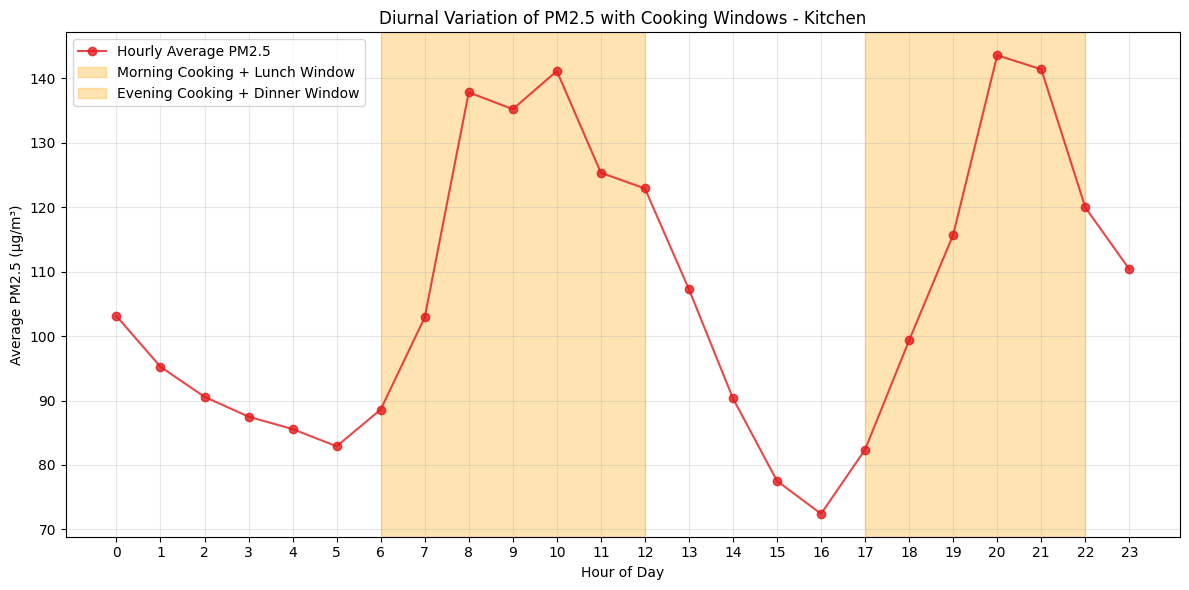


PM2.5 Contribution Analysis for Hall:
                     Period        mean         max        std
0  Evening Cooking + Dinner  113.285795  633.575000  58.708730
1   Morning Cooking + Lunch  115.275361  547.816667  61.241717
2               Non-Cooking   93.057749  540.700000  40.741008

Peak Frequency by Period for Hall:
                     Period  Peak Frequency
0  Evening Cooking + Dinner            6156
1   Morning Cooking + Lunch            7499
2               Non-Cooking            8277

Exposure Contribution by Period for Hall:
                     Period  Exposure Contribution  Exposure Contribution (%)  \
0  Evening Cooking + Dinner           1.329862e+06                  23.383742   
1   Morning Cooking + Lunch           1.581347e+06                  27.805758   
2               Non-Cooking           2.775913e+06                  48.810499   

   Exposure Contribution (%) per hour  
0                            4.676748  
1                            5.561152  
2        

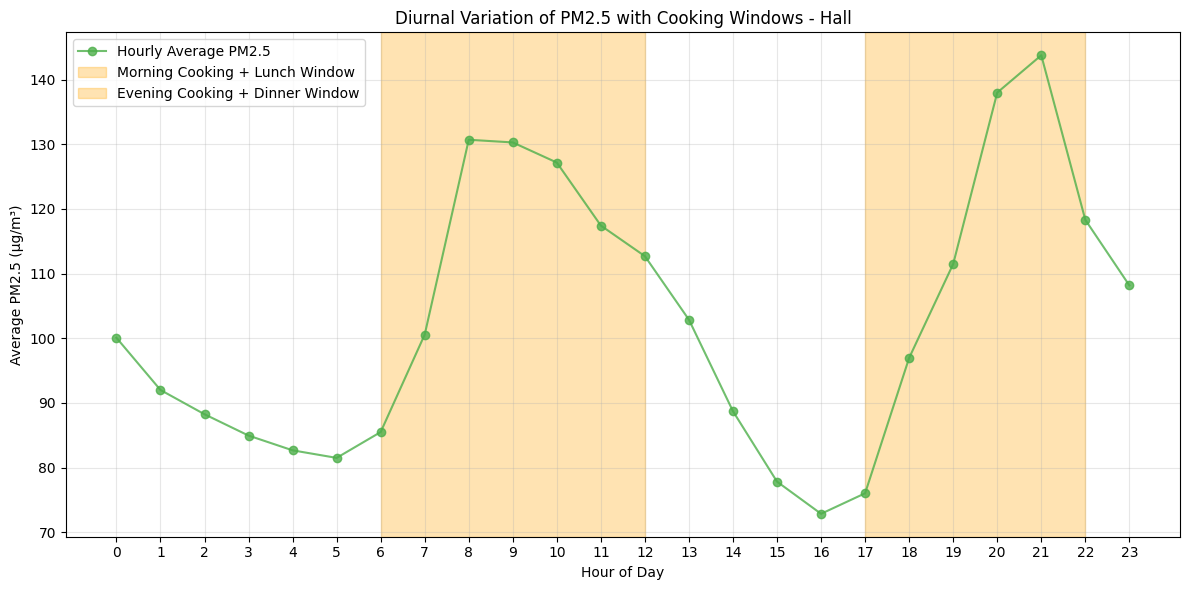


PM2.5 Contribution Analysis for Bedroom:
                     Period       mean         max        std
0  Evening Cooking + Dinner  80.538032  188.400000  26.634434
1   Morning Cooking + Lunch  85.693724  199.980000  28.306895
2               Non-Cooking  77.992069  199.666667  25.142907

Peak Frequency by Period for Bedroom:
                     Period  Peak Frequency
0  Evening Cooking + Dinner            5190
1   Morning Cooking + Lunch            8235
2               Non-Cooking           11318

Exposure Contribution by Period for Bedroom:
                     Period  Exposure Contribution  Exposure Contribution (%)  \
0  Evening Cooking + Dinner           9.454360e+05                  21.348794   
1   Morning Cooking + Lunch           1.158922e+06                  26.169499   
2               Non-Cooking           2.324164e+06                  52.481706   

   Exposure Contribution (%) per hour  
0                            4.269759  
1                            5.233900  
2   

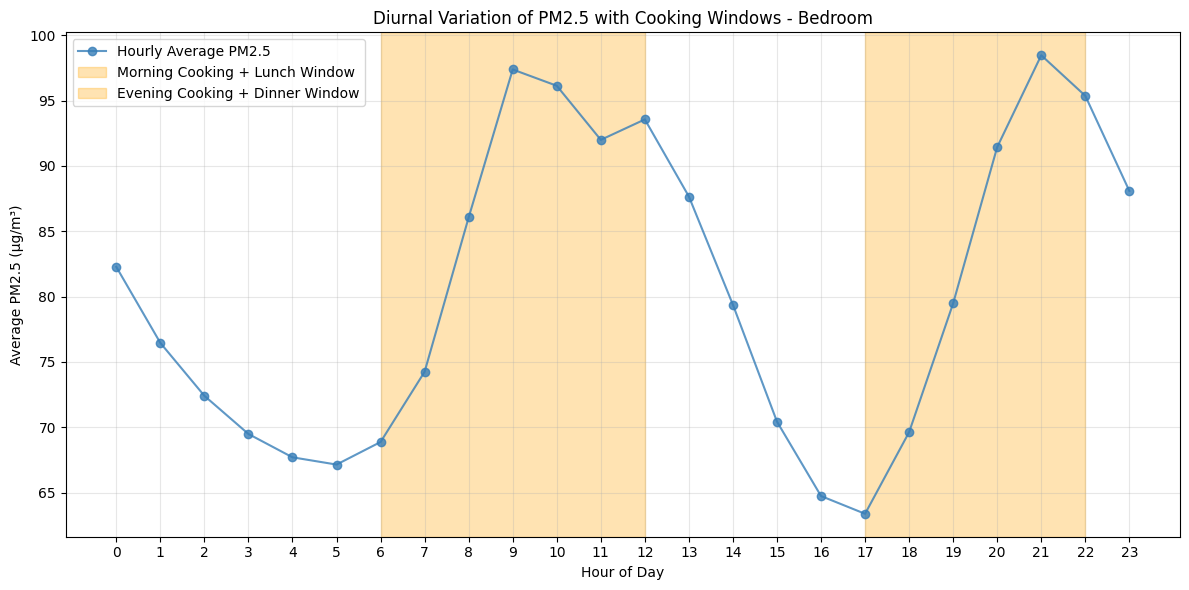

In [23]:
calculate_cooking_related_PM2_5_contribution_analysis(
    room_name="Kitchen", room_df=kitchen, room_colour=kitchen_colour
)
calculate_cooking_related_PM2_5_contribution_analysis(
    room_name="Hall", room_df=hall, room_colour=hall_colour
)
calculate_cooking_related_PM2_5_contribution_analysis(
    room_name="Bedroom", room_df=bedroom, room_colour=bedroom_colour
)

## Decay Rate After Cooking (Ventilation Efficiency Proxy)
- For each major spike Measure time taken for PM2.5 to return to baseline
- We analyze:
  - How long it takes to return to baseline
  - How fast concentration decreases
#### Steps:
- For Each Cooking period, Identify Decay Start
  - The time of maximum concentration within that period.
- Define Baseline
  - Average non-cooking period concentration
- Calculate Decay Duration
  - Start at period maximum concentration time
  - Find first time when PM2.5 returns near baseline
#### Plot:
- Select one representative period (One with maximum duration or maximum concentration)
- Plot concentration vs time for this period
- Highlight:
  - Peak maximum
  - Recovery point
  - Decay slope

In [24]:
from datetime import time


def classify_period_simple(t):
    """
    Morning + Afternoon : 6:00 to 12:00 (From morning tea to Lunch)
    Evening : 17:00 to 22:00 (From evening tea to Dinner)
    Both classified as `Cooking`
    """
    if time(6, 0) <= t <= time(12, 0) or time(17, 0) <= t <= time(22, 0):
        return "Cooking"
    else:
        return "Non-Cooking"

In [28]:
def decay_rate_after_cooking(room_df=None, room_colour=None, room_name=None):
    if room_df is None:
        raise ValueError("room_df is None")
    if room_colour is None:
        raise ValueError("room_colour is None")
    if room_name is None:
        raise ValueError("room_name is None")

    # Keep DateTime index (must be DatetimeIndex for .hour/.date access)
    room_decay_df = room_df[["pm2.5atm"]].copy()
    room_decay_df.index = pd.to_datetime(room_decay_df.index)

    # Basic time features
    room_decay_df["Date"] = room_decay_df.index.date
    room_decay_df["Time"] = room_decay_df.index.time
    room_decay_df["Period"] = room_decay_df["Time"].apply(classify_period_simple)

    # Daily stats (map instead of merge to preserve DateTime index)
    room_daily_avg = room_decay_df.groupby("Date")["pm2.5atm"].mean()
    daily_baseline = room_decay_df.groupby("Date")[
        "pm2.5atm"
    ].mean()  # same as daily avg in current logic
    baseline_margin = 0.4

    room_decay_df["DailyAvg"] = room_decay_df["Date"].map(room_daily_avg)
    room_decay_df["Baseline"] = room_decay_df["Date"].map(daily_baseline)

    baseline_global = room_decay_df.loc[
        room_decay_df["Period"] == "Non-Cooking", "pm2.5atm"
    ].mean()
    room_decay_df["Baseline"] = room_decay_df["Baseline"].fillna(baseline_global)

    # Major spike episodes during cooking
    is_major = (room_decay_df["Period"] == "Cooking") & (
        room_decay_df["pm2.5atm"] > room_decay_df["DailyAvg"]
    )
    start_of_event = is_major & ~is_major.shift(fill_value=False)
    room_decay_df["Event ID"] = start_of_event.cumsum()
    room_decay_df.loc[~is_major, "Event ID"] = np.nan

    # Compute decay metrics
    records = []
    max_decay_hours = 12
    min_consecutive_points = 3

    for event_id in room_decay_df["Event ID"].dropna().unique():
        event_data = room_decay_df[
            room_decay_df["Event ID"] == event_id
        ].sort_index()
        if len(event_data) < 2:
            continue

        max_conc_time = event_data["pm2.5atm"].idxmax()  # Timestamp now
        max_conc_value = event_data["pm2.5atm"].max()
        max_conc_hour = max_conc_time.hour
        max_conc_date = max_conc_time.date()

        threshold = event_data["Baseline"].iloc[0] * (1 + baseline_margin)
        recovery_point = event_data[event_data["pm2.5atm"] <= threshold].index.min()
        if pd.isna(recovery_point):
            recovery_point = event_data.index[-1]

        recovery_hour = recovery_point.hour
        decay_duration = (recovery_point - max_conc_time).total_seconds() / 3600.0

        if decay_duration <= 0 or decay_duration > max_decay_hours:
            continue

        post_peak_data = event_data.loc[max_conc_time:]
        if len(post_peak_data) < min_consecutive_points:
            continue

        initial_conc = max_conc_value
        final_conc = event_data.loc[recovery_point, "pm2.5atm"]
        if isinstance(final_conc, pd.Series):
            final_conc = final_conc.iloc[0]
        decay_rate = (initial_conc - final_conc) / decay_duration

        records.append(
            {
                "Event ID": event_id,
                "Date": max_conc_date,
                "Peak Hour": max_conc_hour,
                "Recovery Hour": recovery_hour,
                "Decay Duration (hours)": decay_duration,
                "Initial Concentration": initial_conc,
                "Final Concentration": final_conc,
                "Decay Rate (µg/m³/hour)": decay_rate,
            }
        )

    decay_df = pd.DataFrame(records)
    if decay_df.empty:
        print(f"\nDecay Rate Analysis After Cooking Events in {room_name}:")
        print("No valid decay events found.")
        return decay_df

    decay_df = decay_df.sort_values(by=["Date", "Peak Hour"]).reset_index(drop=True)

    print(f"\nDecay Rate Analysis After Cooking Events in {room_name}:")
    print(decay_df)
    os.makedirs(os.path.join(PLOT_DIR, "Decay_Rate_Analysis"), exist_ok=True)
    decay_df.to_csv(
        os.path.join(PLOT_DIR, "Decay_Rate_Analysis", f"{room_name}_Decay_Analysis.csv"),
        index=False,
    )

    # Representative event: max decay duration
    rep = decay_df.loc[decay_df["Decay Duration (hours)"].idxmax()]

    # Plot representative event
    rep_event_id = rep["Event ID"]
    event_data = room_decay_df[
        room_decay_df["Event ID"] == rep_event_id
    ].sort_index()

    plt.figure(figsize=(12, 6))
    plt.plot(
        event_data.index,
        event_data["pm2.5atm"],
        marker="o",
        label="PM2.5 Concentration",
        color=room_colour,
        alpha=0.8,
    )
    initial_concentration = rep["Initial Concentration"]
    if isinstance(initial_concentration, pd.Series):
        initial_concentration = initial_concentration.iloc[0]
    plt.axhline(
        y=float(initial_concentration),
        color="red",
        linestyle="-.",
        label="Max Concentration",
        alpha=0.6,
    )
    plt.annotate(
        f"Peak {initial_concentration:.1f}",
        xy=(event_data["pm2.5atm"].idxmax(), event_data["pm2.5atm"].max()),
        xytext=(3, 5),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="red"),
        fontsize=9,
        color="red",
    )

    final_concentration = rep["Final Concentration"]
    if isinstance(final_concentration, pd.Series):
        final_concentration = final_concentration.iloc[0]
    plt.axhline(
        y=float(final_concentration),
        color="green",
        linestyle="-.",
        label="Near Baseline Concentration",
        alpha=0.6,
    )
    plt.annotate(
        f"Recovery {final_concentration:.1f}",
        xy=(event_data.index[-1], event_data["pm2.5atm"].iloc[-1]),
        xytext=(3, -15),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="green"),
        fontsize=9,
        color="green",
    )

    baseline_concentration = event_data["Baseline"].iloc[0]
    if isinstance(baseline_concentration, pd.Series):
        baseline_concentration = baseline_concentration.iloc[0]
    plt.axhline(
        y=float(baseline_concentration),
        color="blue",
        linestyle="-.",
        label="Baseline Concentration",
        alpha=0.6,
    )
    plt.annotate(
        f"Baseline {baseline_concentration:.1f}",
        xy=(event_data.index[0], event_data["Baseline"].iloc[0]),
        xytext=(3, -15),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="blue"),
        fontsize=9,
        color="blue",
    )

    # Decay Rate Annotation
    decay_rate = rep["Decay Rate (µg/m³/hour)"]
    if isinstance(decay_rate, pd.Series):
        decay_rate = decay_rate.iloc[0]

    peak_time = event_data["pm2.5atm"].idxmax()
    peak_value = event_data.loc[peak_time, "pm2.5atm"]
    if isinstance(peak_value, pd.Series):
        peak_value = peak_value.iloc[0]

    recovery_time = event_data.index[-1]
    recovery_value = event_data["pm2.5atm"].iloc[-1]
    if isinstance(recovery_value, pd.Series):
        recovery_value = recovery_value.iloc[0]

    plt.plot(
        [peak_time, recovery_time],
        [float(peak_value), float(recovery_value)],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Decay Rate: {float(decay_rate):.2f} µg/m³/hour",
        alpha=0.7,
    )

    mid_time = peak_time + (recovery_time - peak_time) / 2
    mid_value = (float(peak_value) + float(recovery_value)) / 2
    plt.annotate(
        f"Decay Rate: {float(decay_rate):.2f}",
        xy=(mid_time, mid_value),
        xytext=(-25, -50),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="black",
        rotation=-35
    )

    peak_hour = rep["Peak Hour"]
    if isinstance(peak_hour, pd.Series):
        peak_hour = peak_hour.iloc[0]
    plt.title(
        f"Decay Curve After Cooking Event on {rep['Date']} (Peak Hour: {int(peak_hour)}) (Duration: {rep['Decay Duration (hours)']:.2f} hours, Decay Rate: {rep['Decay Rate (µg/m³/hour)']:.2f})",
        fontweight="bold",
    )
    plt.xlabel("Time")
    plt.ylabel("PM2.5 Concentration (µg/m³)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOT_DIR, "Decay_Rate_Analysis", f"{room_name}_Decay_Curve.png"),
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()

    return decay_df


Decay Rate Analysis After Cooking Events in Kitchen:
    Event ID        Date  Peak Hour  Recovery Hour  Decay Duration (hours)  \
0       23.0  2025-12-31         20             20                0.100000   
1       35.0  2026-01-01         20             20                0.016667   
2       72.0  2026-01-05          7              7                0.033333   
3      131.0  2026-01-11         18             18                0.050000   
4      143.0  2026-01-13         10             10                0.016667   
5      146.0  2026-01-13         19             19                0.016667   
6      189.0  2026-01-18         10             10                0.033333   
7      239.0  2026-01-23          8              8                0.200000   
8      246.0  2026-01-23         19             19                0.016667   
9      250.0  2026-01-23         21             21                0.050000   
10     255.0  2026-01-24          8              8                0.033333   
11     258

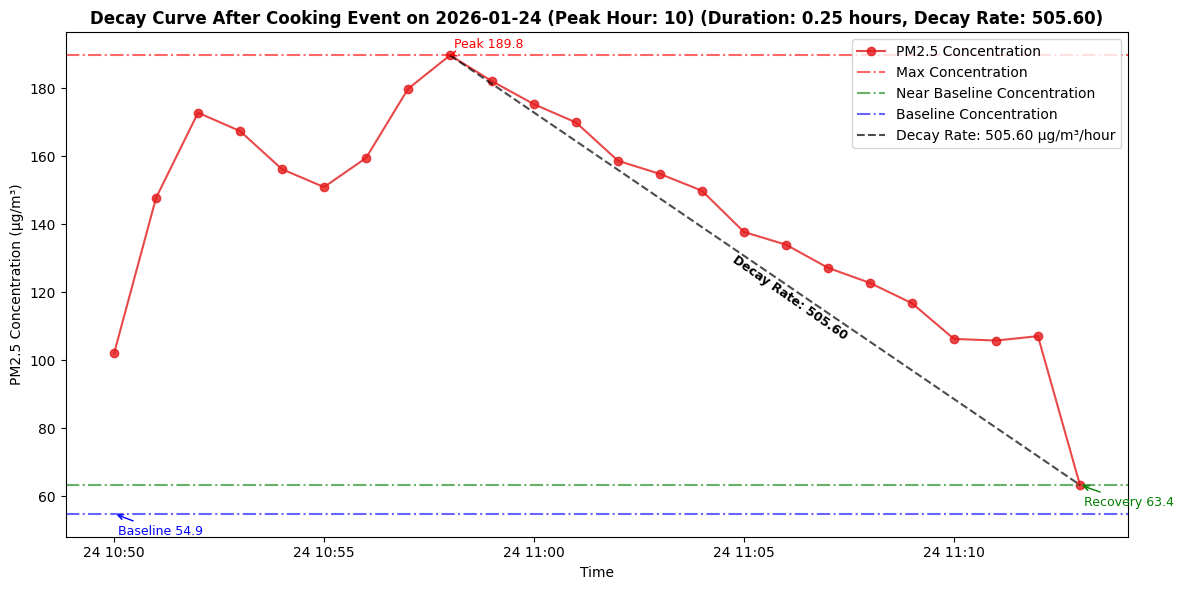


Decay Rate Analysis After Cooking Events in Hall:
   Event ID        Date  Peak Hour  Recovery Hour  Decay Duration (hours)  \
0      23.0  2026-01-01         18             18                0.066667   
1     151.0  2026-01-18          9              9                0.016667   
2     284.0  2026-02-02          8              8                0.033333   
3     317.0  2026-02-04         17             17                0.050000   

   Initial Concentration  Final Concentration  Decay Rate (µg/m³/hour)  
0             192.600000           112.250000              1205.250000  
1             246.900000            83.983333              9775.000000  
2             413.691667           224.950000              5662.250000  
3             501.788889           496.666667               102.444444  


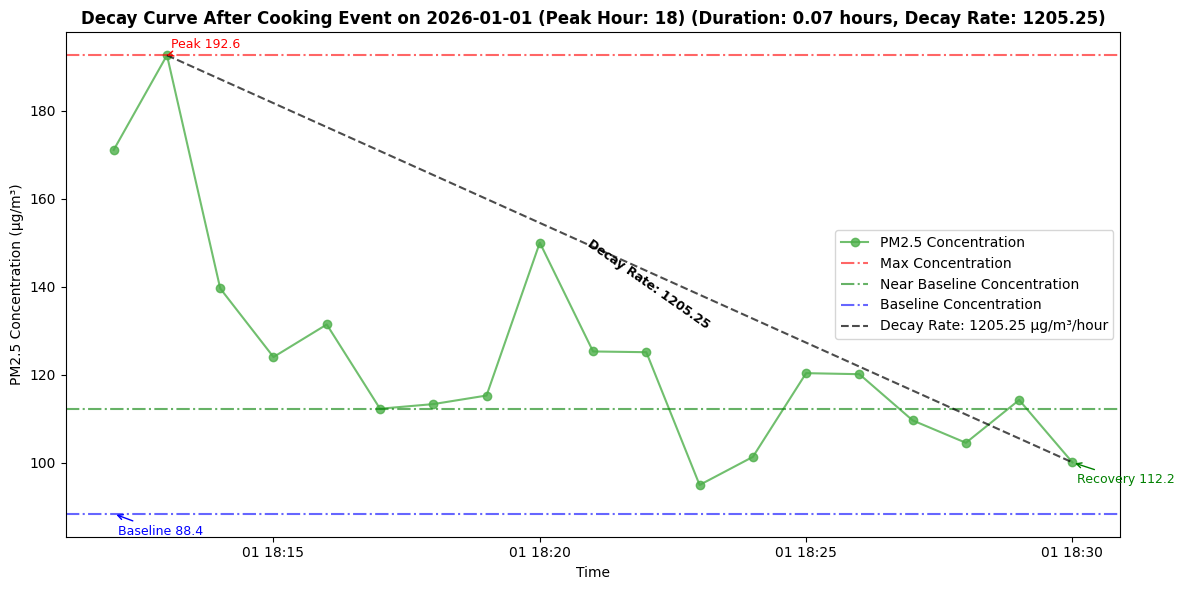


Decay Rate Analysis After Cooking Events in Bedroom:
   Event ID        Date  Peak Hour  Recovery Hour  Decay Duration (hours)  \
0      33.0  2026-01-02          8              8                0.016667   
1      43.0  2026-01-02         21             21                0.200000   
2      68.0  2026-01-06         20             20                0.083333   
3      69.0  2026-01-06         20             20                0.500000   

   Initial Concentration  Final Concentration  Decay Rate (µg/m³/hour)  
0              86.300000            73.950000               741.000000  
1              93.777778            81.866667                59.555556  
2             100.866667            85.533333               184.000000  
3             105.733333            85.055556                41.355556  


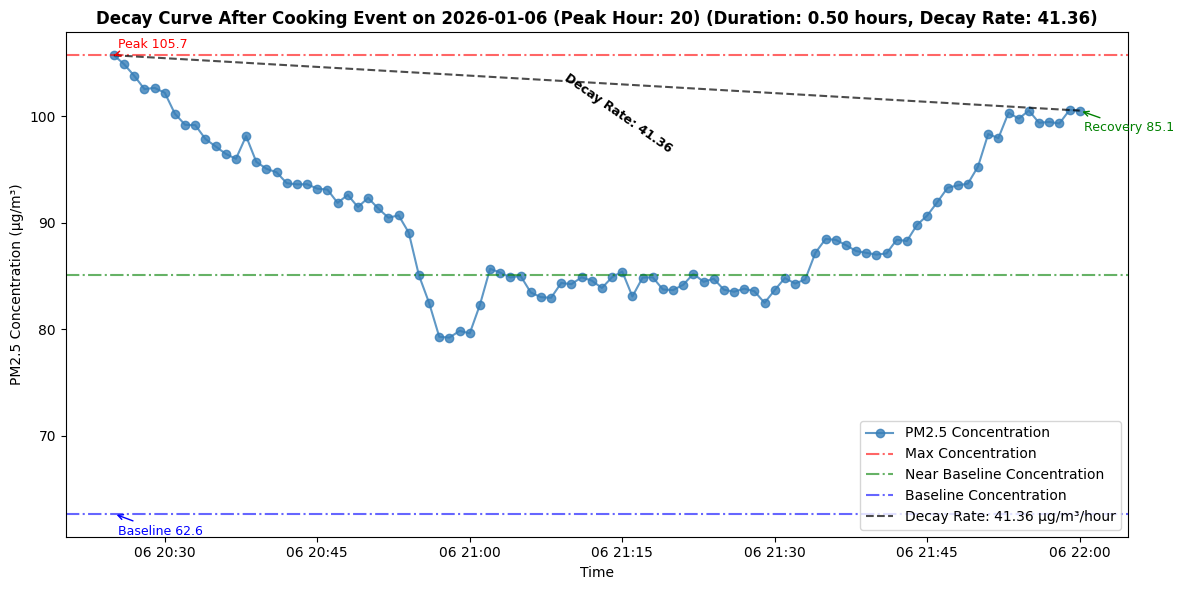

Average Decay Rate After Cooking Events - Kitchen: 2180.49
Average Decay Rate After Cooking Events - Hall: 4186.24
Average Decay Rate After Cooking Events - Bedroom: 256.48
Average Decay Duration After Cooking Events - Kitchen: 0.06 hours
Average Decay Duration After Cooking Events - Hall: 0.04 hours
Average Decay Duration After Cooking Events - Bedroom: 0.20 hours


In [30]:
kitchen_decay_df = decay_rate_after_cooking(room_df=kitchen, room_colour=kitchen_colour, room_name="Kitchen")
hall_decay_df = decay_rate_after_cooking(room_df=hall, room_colour=hall_colour, room_name="Hall")
bedroom_decay_df = decay_rate_after_cooking(room_df=bedroom, room_colour=bedroom_colour, room_name="Bedroom")

print(f"Average Decay Rate After Cooking Events - Kitchen: {kitchen_decay_df['Decay Rate (µg/m³/hour)'].mean():.2f}")
print(f"Average Decay Rate After Cooking Events - Hall: {hall_decay_df['Decay Rate (µg/m³/hour)'].mean():.2f}")
print(f"Average Decay Rate After Cooking Events - Bedroom: {bedroom_decay_df['Decay Rate (µg/m³/hour)'].mean():.2f}")

print(f"Average Decay Duration After Cooking Events - Kitchen: {kitchen_decay_df['Decay Duration (hours)'].mean():.2f} hours")
print(f"Average Decay Duration After Cooking Events - Hall: {hall_decay_df['Decay Duration (hours)'].mean():.2f} hours")
print(f"Average Decay Duration After Cooking Events - Bedroom: {bedroom_decay_df['Decay Duration (hours)'].mean():.2f} hours")